# Healthcare Data Analytics Project

## Project Overview

This project analyzes real-world healthcare datasets from CMS (Centers for Medicare & Medicaid Services) to identify trends in:

- Hospital complications and deaths
- Patient satisfaction
- Medicare spending
- Timely and effective care

The project uses Python, pandas, NumPy, and matplotlib for data cleaning, exploratory data analysis (EDA), visualization, correlation analysis, and regression analysis.

## Business Questions

- Do hospitals with higher Medicare spending achieve higher patient satisfaction?
- Which states show the highest complication and outcome scores?
- How does patient satisfaction vary across hospitals and states?
- Are there measurable relationships between healthcare spending and healthcare quality?

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Google Colab
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Correlation Analysis
- Regression Analysis
- Data Visualization

# Data Collection & Dataset Loading

In this section, we load multiple CMS healthcare datasets containing:
- Hospital complications and mortality
- Patient satisfaction surveys
- Medicare spending data
- Timely and effective care metrics

These datasets will be cleaned and analyzed throughout the project.

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)

# Load datasets
complications_df = pd.read_csv('/content/complications_and_deaths_hospital.csv')

hcahps_df = pd.read_csv(
    '/content/hcahps_hospital.csv',
    low_memory=False
)

medicare_df = pd.read_csv(
    '/content/medicare_hospital_spending_per_patient_hospital.csv'
)

timely_df = pd.read_csv(
    '/content/timely_and_effective_care_hospital.csv'
)

# Verify datasets loaded
print("Complications shape:", complications_df.shape)
print("HCAHPS shape:", hcahps_df.shape)
print("Medicare shape:", medicare_df.shape)
print("Timely & Effective Care shape:", timely_df.shape)

Complications shape: (90801, 18)
HCAHPS shape: (444447, 22)
Medicare shape: (4615, 14)
Timely & Effective Care shape: (118520, 16)


In [ ]:
# Preview first rows
complications_df.head()

,facility_id,facility_name,address,citytown,state,zip_code,countyparish,telephone_number,measure_id,measure_name,compared_to_national,denominator,score,lower_estimate,higher_estimate,footnote,start_date,end_date
0,10001.0,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,COMP_HIP_KNEE,Rate of complications for hip/knee replacement...,No Different Than the National Rate,32.0,3.0,1.6,5.5,NaN,2020-07-01,2023-03-31
1,10001.0,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_AMI,Death rate for heart attack patients,No Different Than the National Rate,291.0,10.8,8.4,13.6,NaN,2020-07-01,2023-06-30
2,10001.0,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_CABG,Death rate for CABG surgery patients,No Different Than the National Rate,157.0,3.8,2.1,6.8,NaN,2020-07-01,2023-06-30
3,10001.0,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_COPD,Death rate for COPD patients,No Different Than the National Rate,122.0,7.9,5.2,11.9,NaN,2020-07-01,2023-06-30
4,10001.0,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_HF,Death rate for heart failure patients,No Different Than the National Rate,610.0,10.5,8.6,12.9,NaN,2020-07-01,2023-06-30


In [ ]:
# Dataset info
complications_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90801 entries, 0 to 90800
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   facility_id           87685 non-null  float64
 1   facility_name         90801 non-null  object 
 2   address               90801 non-null  object 
 3   citytown              90801 non-null  object 
 4   state                 90801 non-null  object 
 5   zip_code              90801 non-null  int64  
 6   countyparish          90801 non-null  object 
 7   telephone_number      90801 non-null  object 
 8   measure_id            90801 non-null  object 
 9   measure_name          90801 non-null  object 
 10  compared_to_national  90801 non-null  object 
 11  denominator           45970 non-null  float64
 12  score                 48934 non-null  float64
 13  lower_estimate        48934 non-null  float64
 14  higher_estimate       48934 non-null  float64
 15  footnote           

# Data Cleaning & Preparation

Healthcare datasets often contain:
- Missing values
- Incorrect datatypes
- Duplicate records
- Inconsistent formatting

This section prepares the datasets for accurate analysis.

In [ ]:
# Check missing values
complications_df.isnull().sum()

,0
facility_id,3116
facility_name,0
address,0
citytown,0
state,0
zip_code,0
countyparish,0
telephone_number,0
measure_id,0
measure_name,0


In [ ]:
# Numeric columns to convert
numeric_cols = [
    'denominator',
    'score',
    'lower_estimate',
    'higher_estimate'
]

# Convert safely
for col in numeric_cols:
    complications_df[col] = pd.to_numeric(
        complications_df[col],
        errors='coerce'
    )

# Verify datatypes
complications_df[numeric_cols].dtypes

,0
denominator,float64
score,float64
lower_estimate,float64
higher_estimate,float64


In [ ]:
# Convert date columns
complications_df['start_date'] = pd.to_datetime(
    complications_df['start_date'],
    errors='coerce'
)

complications_df['end_date'] = pd.to_datetime(
    complications_df['end_date'],
    errors='coerce'
)

# Verify datatypes
complications_df[['start_date', 'end_date']].dtypes

,0
start_date,datetime64[ns]
end_date,datetime64[ns]


In [ ]:
# Check duplicate rows
duplicate_count = complications_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [ ]:
# Fill missing numeric values with 0
numeric_cols = [
    'denominator',
    'score',
    'lower_estimate',
    'higher_estimate'
]

complications_df[numeric_cols] = complications_df[
    numeric_cols
].fillna(0)

# Fill missing text/object values with 'Unknown'
text_cols = complications_df.select_dtypes(
    include='object'
).columns

complications_df[text_cols] = complications_df[
    text_cols
].fillna('Unknown')

# Verify missing values
complications_df.isnull().sum()

,0
facility_id,3116
facility_name,0
address,0
citytown,0
state,0
zip_code,0
countyparish,0
telephone_number,0
measure_id,0
measure_name,0


In [ ]:
# Strip whitespace from text columns
text_cols = complications_df.select_dtypes(
    include='object'
).columns

for col in text_cols:
    complications_df[col] = complications_df[col].str.strip()

# Create cleaned dataframe copy
complications_cleaned_df = complications_df.copy()

# Verify dataset info
complications_cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90801 entries, 0 to 90800
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   facility_id           87685 non-null  float64       
 1   facility_name         90801 non-null  object        
 2   address               90801 non-null  object        
 3   citytown              90801 non-null  object        
 4   state                 90801 non-null  object        
 5   zip_code              90801 non-null  int64         
 6   countyparish          90801 non-null  object        
 7   telephone_number      90801 non-null  object        
 8   measure_id            90801 non-null  object        
 9   measure_name          90801 non-null  object        
 10  compared_to_national  90801 non-null  object        
 11  denominator           90801 non-null  float64       
 12  score                 90801 non-null  float64       
 13  lower_estimate  

In [ ]:
# Save cleaned dataset
complications_cleaned_df.to_csv(
    '/content/complications_cleaned_final.csv',
    index=False
)

print("Cleaned complications dataset saved.")

Cleaned complications dataset saved.


In [ ]:
# Summary statistics for numeric columns
complications_cleaned_df[
    ['score', 'denominator', 'lower_estimate', 'higher_estimate']
].describe()

,score,denominator,lower_estimate,higher_estimate
count,90801.000000,90801.000000,90801.000000,90801.000000
mean,6.034206,598.313862,3.997938,8.285794
std,23.531840,1902.382486,17.149939,30.103884
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.270000,26.000000,0.000000,0.490000
75%,3.660000,275.000000,1.160000,6.260000
max,258.280000,57005.000000,220.220000,302.620000


# Exploratory Data Analysis (EDA)

This section explores:
- Distribution of hospital scores
- Outliers
- Correlations between healthcare metrics
- State-level healthcare performance

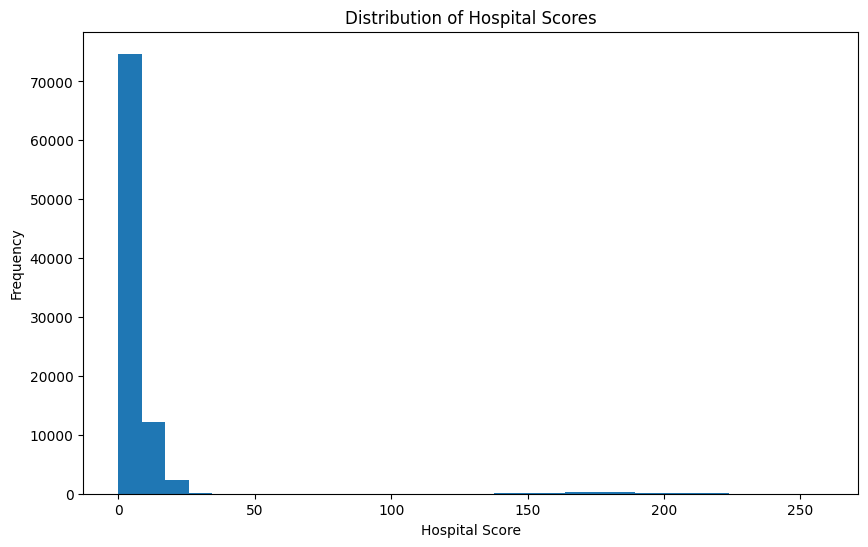

In [ ]:
# Histogram of hospital scores
plt.figure(figsize=(10,6))

plt.hist(
    complications_cleaned_df['score'],
    bins=30
)

# Labels and title
plt.xlabel('Hospital Score')
plt.ylabel('Frequency')
plt.title('Distribution of Hospital Scores')

plt.show()

In [ ]:
# Calculate IQR for outlier detection
Q1 = complications_cleaned_df['score'].quantile(0.25)
Q3 = complications_cleaned_df['score'].quantile(0.75)

IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = complications_cleaned_df[
    (complications_cleaned_df['score'] < lower_bound) |
    (complications_cleaned_df['score'] > upper_bound)
]

# Display results
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", outliers.shape[0])

outliers[
    ['facility_name', 'citytown', 'state',
     'measure_name', 'score']
].head(15)

Lower Bound: -5.49
Upper Bound: 9.15
Number of Outliers: 15321


,facility_name,citytown,state,measure_name,score
1,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,Death rate for heart attack patients,10.80
4,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,Death rate for heart failure patients,10.50
5,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,Death rate for pneumonia patients,18.90
6,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,Death rate for stroke patients,13.70
8,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,Death rate among surgical inpatients with seri...,194.78
13,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,Postoperative respiratory failure rate,12.33
20,MARSHALL MEDICAL CENTERS,BOAZ,AL,Death rate for heart attack patients,14.50
22,MARSHALL MEDICAL CENTERS,BOAZ,AL,Death rate for COPD patients,9.20
23,MARSHALL MEDICAL CENTERS,BOAZ,AL,Death rate for heart failure patients,12.70
24,MARSHALL MEDICAL CENTERS,BOAZ,AL,Death rate for pneumonia patients,23.10


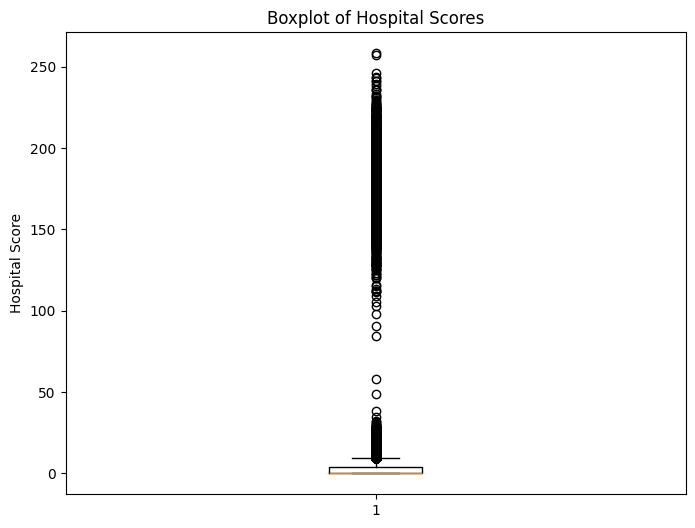

In [ ]:
# Boxplot of hospital scores
plt.figure(figsize=(8,6))

plt.boxplot(
    complications_cleaned_df['score']
)

# Labels and title
plt.ylabel('Hospital Score')
plt.title('Boxplot of Hospital Scores')

plt.show()

In [ ]:
# Correlation matrix
correlation_matrix = complications_cleaned_df[
    ['score', 'denominator', 'lower_estimate', 'higher_estimate']
].corr()

# Display correlation matrix
correlation_matrix

,score,denominator,lower_estimate,higher_estimate
score,1.000000,-0.049875,0.994773,0.998116
denominator,-0.049875,1.000000,-0.048333,-0.051802
lower_estimate,0.994773,-0.048333,1.000000,0.986853
higher_estimate,0.998116,-0.051802,0.986853,1.000000


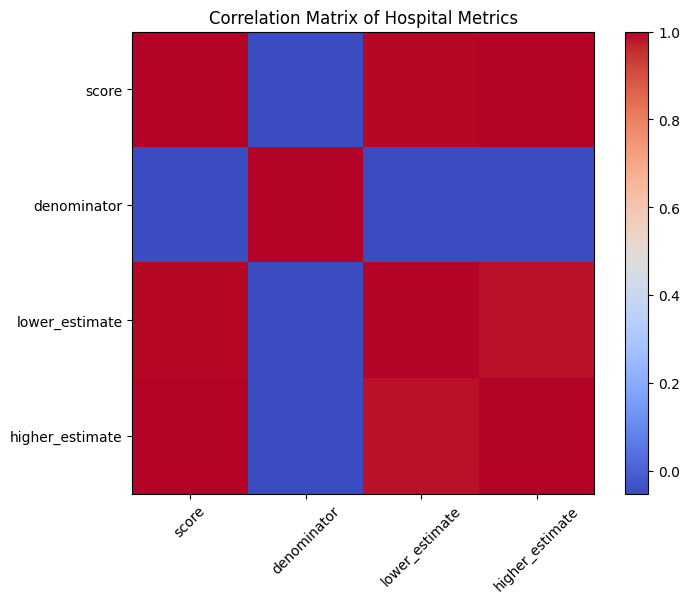

In [ ]:
# Heatmap of correlation matrix
plt.figure(figsize=(8,6))

plt.imshow(
    correlation_matrix,
    cmap='coolwarm',
    interpolation='nearest'
)

# Labels
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Color bar
plt.colorbar()

# Title
plt.title('Correlation Matrix of Hospital Metrics')

plt.show()

In [ ]:
# Average score by measure
measure_avg_scores = complications_cleaned_df.groupby(
    'measure_name'
)['score'].mean().sort_values(ascending=False)

# Top 10 highest average complication measures
top_measures = measure_avg_scores.head(10)

# Display results
top_measures

,score
measure_name,
Death rate among surgical inpatients with serious treatable complications,58.375049
Death rate for pneumonia patients,13.692237
Death rate for heart failure patients,7.847772
Death rate for stroke patients,6.376313
Postoperative respiratory failure rate,5.523963
Death rate for heart attack patients,5.281440
Death rate for COPD patients,5.232392
Postoperative sepsis rate,2.892348
Perioperative pulmonary embolism or deep vein thrombosis rate,2.350465


In [ ]:
# Bottom 10 lowest average complication measures
lowest_measures = measure_avg_scores.tail(10)

# Display results
lowest_measures

,score
measure_name,
Postoperative hemorrhage or hematoma rate,1.467625
Rate of complications for hip/knee replacement patients,1.252542
Postoperative wound dehiscence rate,0.992911
Postoperative acute kidney injury requiring dialysis rate,0.889688
CMS Medicare PSI 90: Patient safety and adverse events composite,0.619734
Death rate for CABG surgery patients,0.545323
Abdominopelvic accidental puncture or laceration rate,0.534308
Pressure ulcer rate,0.417702
In-hospital fall-associated fracture rate,0.192306


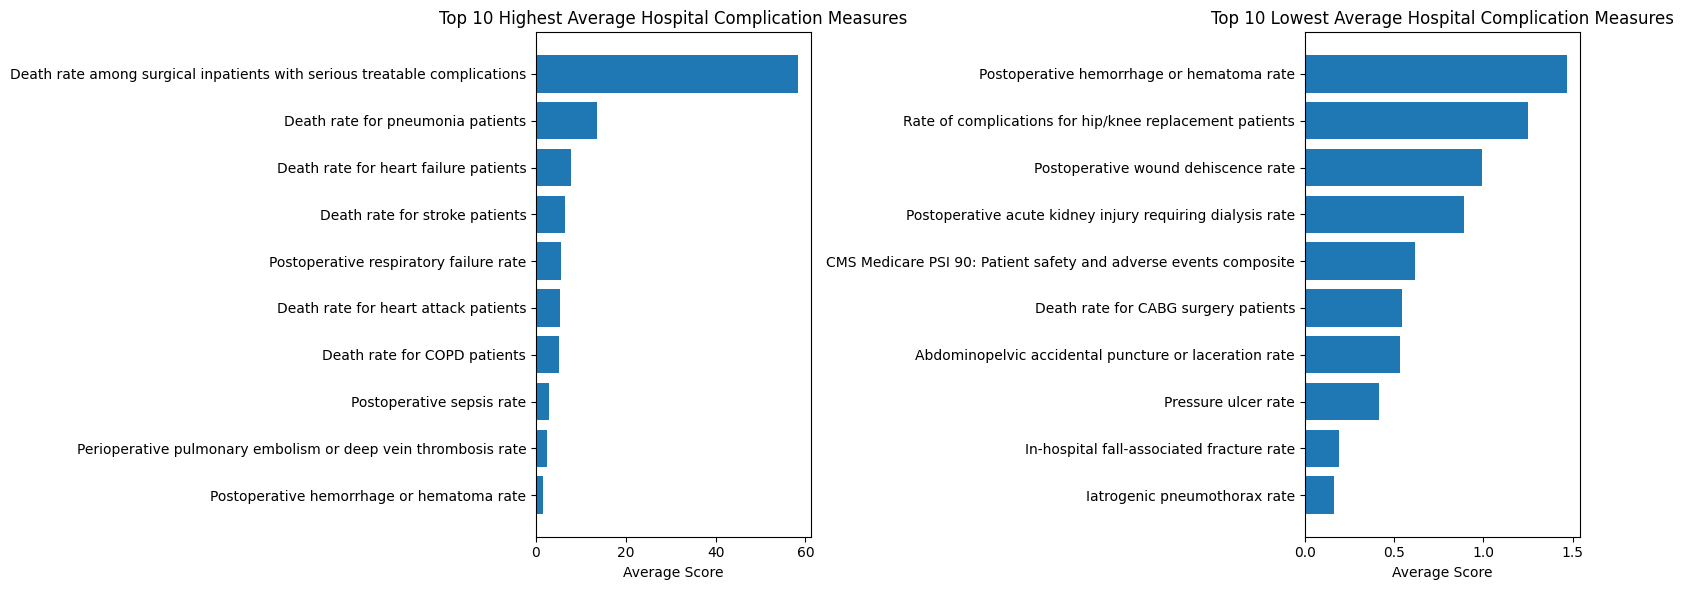

In [ ]:
import matplotlib.pyplot as plt

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Top measures chart
axes[0].barh(top_measures.index, top_measures.values)
axes[0].set_title('Top 10 Highest Average Hospital Complication Measures')
axes[0].set_xlabel('Average Score')
axes[0].invert_yaxis()

# Lowest measures chart
axes[1].barh(lowest_measures.index, lowest_measures.values)
axes[1].set_title('Top 10 Lowest Average Hospital Complication Measures')
axes[1].set_xlabel('Average Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# State-Level Healthcare Analysis

This section identifies:
- Highest-risk states
- Lowest-risk states
- Regional healthcare trends
- State performance comparisons

In [ ]:
# Average score by state
state_avg_scores = complications_cleaned_df.groupby(
    'state'
)['score'].mean().sort_values(ascending=False)

# Top 10 highest-risk states
top_10_states = state_avg_scores.head(10)

# Bottom 10 lowest-risk states
bottom_10_states = state_avg_scores.tail(10)

# Display results
top_10_states, bottom_10_states

(state
 NJ    11.309093
 MD    10.741469
 DC    10.497368
 FL     9.769033
 CT     9.392368
 MA     8.825279
 NY     8.159693
 VA     8.143533
 SC     7.827985
 DE     7.672105
 Name: score, dtype: float64,
 state
 MN    2.954952
 MP    2.863158
 WY    2.862468
 VI    2.697368
 ND    2.674082
 MT    2.542029
 SD    2.085386
 GU    1.936842
 PR    0.733512
 AS    0.000000
 Name: score, dtype: float64)

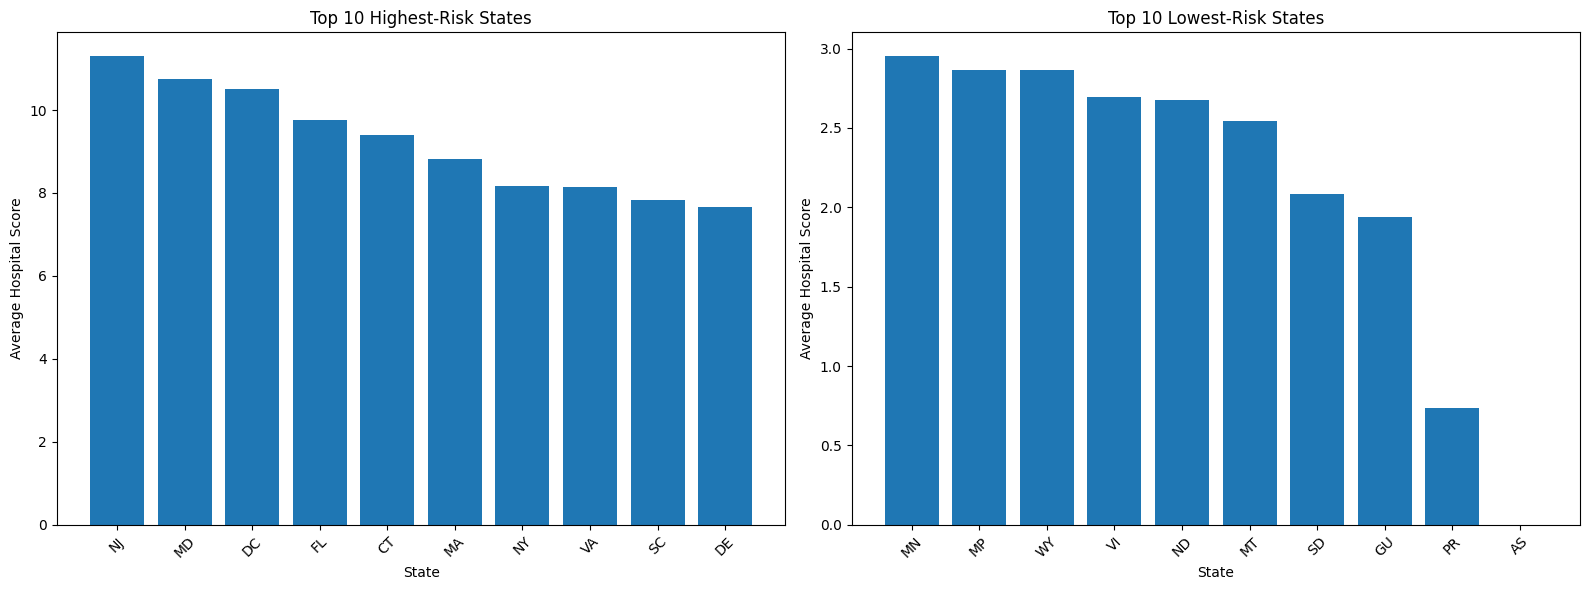

In [ ]:
import matplotlib.pyplot as plt

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Highest-risk states
axes[0].bar(top_10_states.index, top_10_states.values)
axes[0].set_title('Top 10 Highest-Risk States')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Average Hospital Score')
axes[0].tick_params(axis='x', rotation=45)

# Lowest-risk states
axes[1].bar(bottom_10_states.index, bottom_10_states.values)
axes[1].set_title('Top 10 Lowest-Risk States')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Average Hospital Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Average hospital scores by facility
hospital_scores = complications_cleaned_df.groupby(
    'facility_name'
)['score'].mean().sort_values(ascending=False)

# Top 10 highest-risk hospitals
top_hospitals_avg = hospital_scores.head(10)

# Bottom 10 lowest-risk hospitals
bottom_hospitals_avg = hospital_scores.tail(10)

# Display results
top_hospitals_avg, bottom_hospitals_avg

(facility_name
 JACKSON HEALTH SYSTEM                        19.642632
 MARION COMMUNTIY HOSPITAL                    19.489474
 UNITED HEALTH SERVICES HOSPITALS, INC        19.344211
 MERCYONE SIOUXLAND MEDICAL CENTER            18.863684
 HUNTSVILLE HOSPITAL                          18.698947
 NORTHEAST ALABAMA REGIONAL MEDICAL CENTER    18.570000
 LEGACY EMANUEL MEDICAL CENTER                18.545789
 OWENSBORO HEALTH REGIONAL HOSPITAL           18.495263
 NORMAN REGIONAL                              18.423158
 BUTLER MEMORIAL HOSPITAL                     18.370000
 Name: score, dtype: float64,
 facility_name
 TEXAS CHILDRENS HOSP                 0.0
 KAHUKU MEDICAL CENTER                0.0
 JEWELL COUNTY HOSPITAL               0.0
 FRANCISCAN BEACON HOSPITAL, LLC      0.0
 JOHNSON COUNTY COMMUNITY HOSPITAL    0.0
 OTHELLO COMMUNITY HOSPITAL           0.0
 MARY BRIDGE CHILDREN'S HOSPITAL      0.0
 MASON DISTRICT HOSPITAL              0.0
 MARLETTE REGIONAL HOSPITAL           0.0
 T

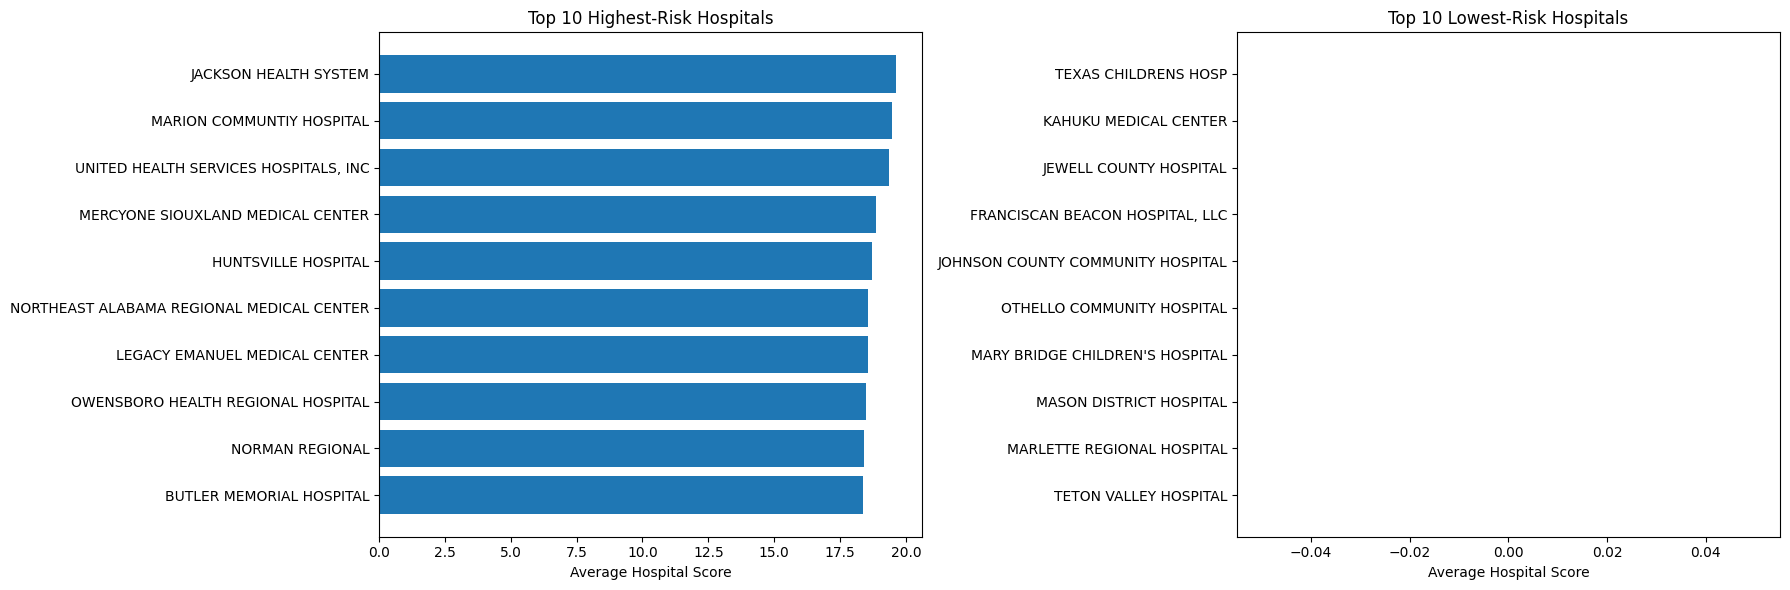

In [ ]:
import matplotlib.pyplot as plt

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Highest-risk hospitals
axes[0].barh(top_hospitals_avg.index, top_hospitals_avg.values)
axes[0].set_title('Top 10 Highest-Risk Hospitals')
axes[0].set_xlabel('Average Hospital Score')
axes[0].invert_yaxis()

# Lowest-risk hospitals
axes[1].barh(bottom_hospitals_avg.index, bottom_hospitals_avg.values)
axes[1].set_title('Top 10 Lowest-Risk Hospitals')
axes[1].set_xlabel('Average Hospital Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Time Trend Analysis

This section analyzes how hospital complication scores changed over time and identifies trends among high-risk states and healthcare measures.

In [ ]:
# Extract year from start_date
complications_cleaned_df['year'] = complications_cleaned_df['start_date'].dt.year

# Average score by year
yearly_scores = complications_cleaned_df.groupby(
    'year'
)['score'].mean()

# Display results
yearly_scores

,score
year,
2020,5.746860
2021,6.201824


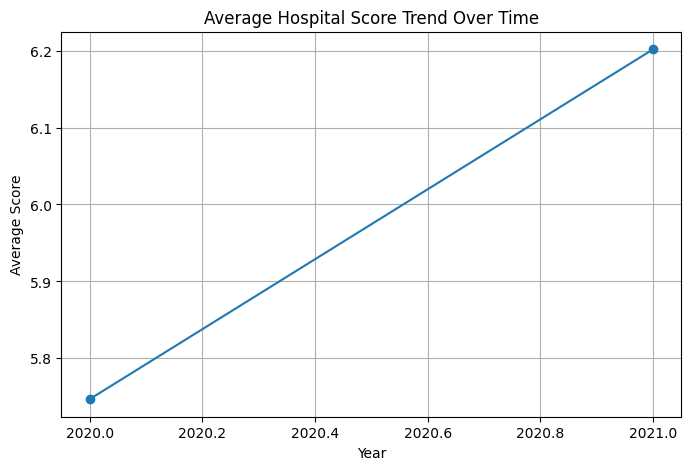

In [ ]:
# Plot yearly hospital score trends
plt.figure(figsize=(8,5))

plt.plot(
    yearly_scores.index,
    yearly_scores.values,
    marker='o'
)

plt.title('Average Hospital Score Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Average Score')

plt.grid(True)

plt.show()

In [ ]:
# High-risk states to analyze
high_risk_states = ['NJ', 'MD', 'DC', 'FL', 'CT']

# Filter dataframe
high_risk_df = complications_cleaned_df[
    complications_cleaned_df['state'].isin(high_risk_states)
]

# Average score by year and state
state_trends = high_risk_df.groupby(
    ['year', 'state']
)['score'].mean().reset_index()

# Display results
state_trends.head()

,year,state,score
0,2020,CT,7.626667
1,2020,DC,6.850000
2,2020,FL,7.906881
3,2020,MD,8.093155
4,2020,NJ,8.583077


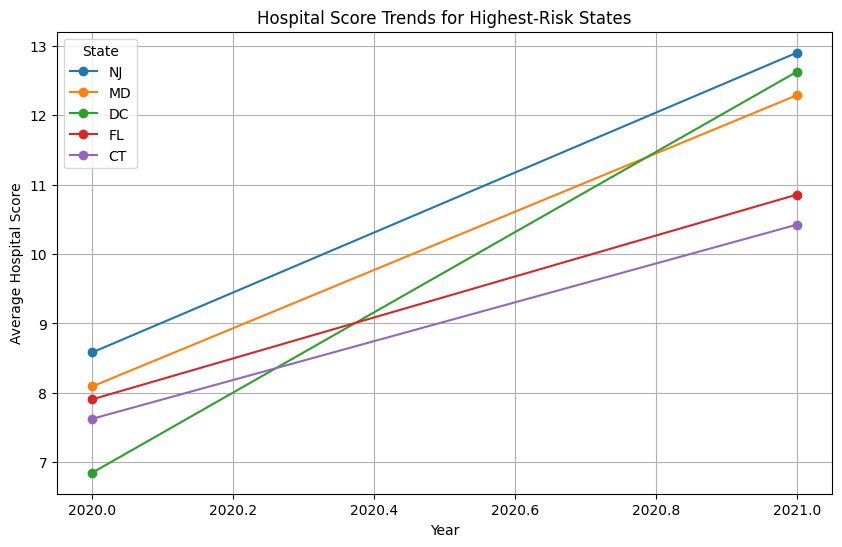

In [ ]:
# Plot trends for high-risk states
plt.figure(figsize=(10,6))

for state in high_risk_states:
    state_data = state_trends[state_trends['state'] == state]

    plt.plot(
        state_data['year'],
        state_data['score'],
        marker='o',
        label=state
    )

plt.title('Hospital Score Trends for Highest-Risk States')
plt.xlabel('Year')
plt.ylabel('Average Hospital Score')

plt.legend(title='State')
plt.grid(True)

plt.show()

In [ ]:
# Average score by year and complication measure
measure_trends = complications_cleaned_df.groupby(
    ['year', 'measure_name']
)['score'].mean().reset_index()

# Display sample results
measure_trends.head()

,year,measure_name,score
0,2020,Death rate for CABG surgery patients,0.545323
1,2020,Death rate for COPD patients,5.232392
2,2020,Death rate for heart attack patients,5.281440
3,2020,Death rate for heart failure patients,7.847772
4,2020,Death rate for pneumonia patients,13.692237


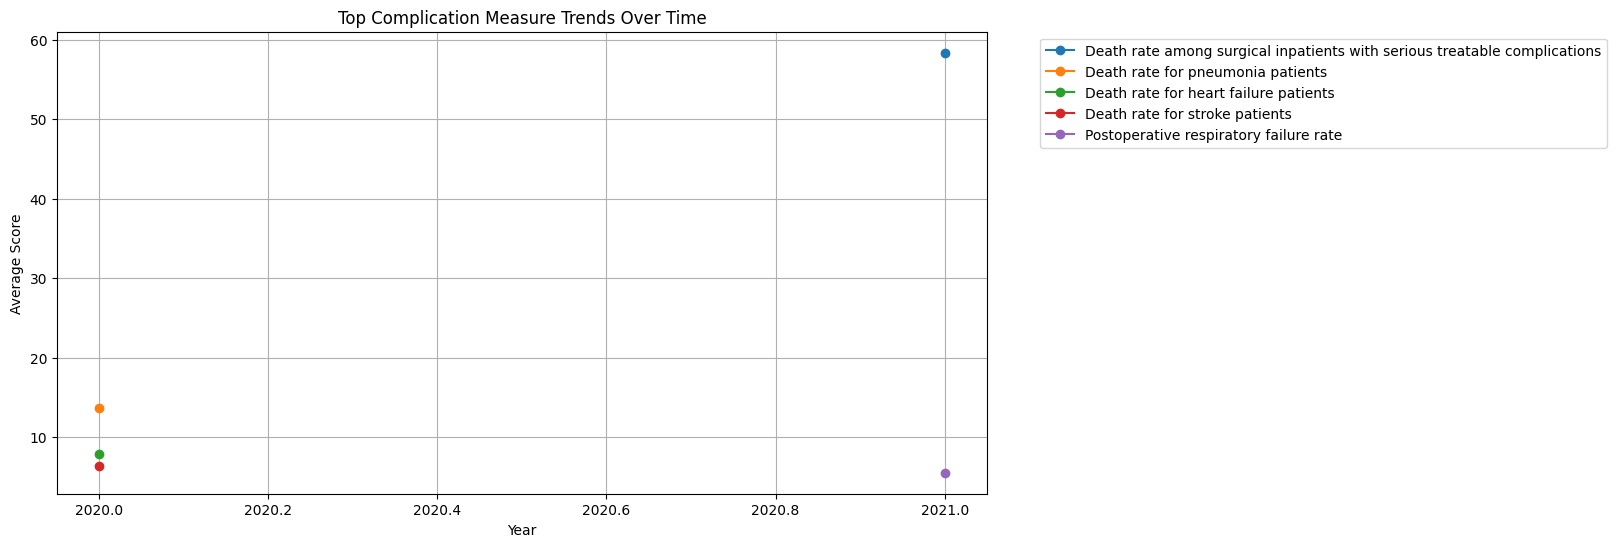

In [ ]:
# Top complication measures to visualize
top_measure_names = top_measures.index.tolist()[:5]

# Filter trend data
top_measure_trends = measure_trends[
    measure_trends['measure_name'].isin(top_measure_names)
]

# Plot trends
plt.figure(figsize=(12,6))

for measure in top_measure_names:
    measure_data = top_measure_trends[
        top_measure_trends['measure_name'] == measure
    ]

    plt.plot(
        measure_data['year'],
        measure_data['score'],
        marker='o',
        label=measure
    )

plt.title('Top Complication Measure Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Average Score')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)

plt.show()

# Patient Satisfaction Analysis

Patient satisfaction is an important healthcare quality metric.

This section analyzes HCAHPS survey data to evaluate:
- Nurse communication
- Hospital satisfaction trends
- Top and bottom-performing hospitals
- State-level satisfaction differences

In [ ]:
# Load HCAHPS dataset
hcahps_df = pd.read_csv(
    '/content/hcahps_hospital.csv',
    low_memory=False
)

# Display basic info
print("Shape:", hcahps_df.shape)

hcahps_df.info()

Shape: (444447, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 444447 entries, 0 to 444446
Data columns (total 22 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   facility_id                      429195 non-null  float64
 1   facility_name                    444447 non-null  object 
 2   address                          444447 non-null  object 
 3   citytown                         444447 non-null  object 
 4   state                            444447 non-null  object 
 5   zip_code                         444447 non-null  int64  
 6   countyparish                     444447 non-null  object 
 7   telephone_number                 444447 non-null  object 
 8   hcahps_measure_id                444447 non-null  object 
 9   hcahps_question                  444447 non-null  object 
 10  hcahps_answer_description        444447 non-null  object 
 11  patient_survey_star_rating       444447 non-n

In [ ]:
# Check missing values
hcahps_df.isnull().sum()

,0
facility_id,15252
facility_name,0
address,0
citytown,0
state,0
zip_code,0
countyparish,0
telephone_number,0
hcahps_measure_id,0
hcahps_question,0


In [ ]:
# Convert dates
hcahps_df['start_date'] = pd.to_datetime(hcahps_df['start_date'])
hcahps_df['end_date'] = pd.to_datetime(hcahps_df['end_date'])

# Convert numeric columns
numeric_cols = [
    'hcahps_answer_percent',
    'number_of_completed_surveys',
    'survey_response_rate_percent'
]

for col in numeric_cols:
    hcahps_df[col] = pd.to_numeric(hcahps_df[col], errors='coerce')

# Drop columns with excessive missing values
drop_cols = [
    'patient_survey_star_rating_fn',
    'hcahps_answer_percent_footnote',
    'number_of_completed_surveys_fn',
    'survey_response_rate_percent_fn'
]

hcahps_cleaned = hcahps_df.drop(columns=drop_cols)

# Verify cleaned dataframe
hcahps_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 444447 entries, 0 to 444446
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   facility_id                   429195 non-null  float64       
 1   facility_name                 444447 non-null  object        
 2   address                       444447 non-null  object        
 3   citytown                      444447 non-null  object        
 4   state                         444447 non-null  object        
 5   zip_code                      444447 non-null  int64         
 6   countyparish                  444447 non-null  object        
 7   telephone_number              444447 non-null  object        
 8   hcahps_measure_id             444447 non-null  object        
 9   hcahps_question               444447 non-null  object        
 10  hcahps_answer_description     444447 non-null  object        
 11  patient_surve

In [ ]:
# Average patient satisfaction by state

state_satisfaction = (
    hcahps_cleaned.groupby('state')['hcahps_linear_mean_value']
    .count()
    .sort_values(ascending=False)
)

# Display top states by response volume
state_satisfaction.head(10)

,hcahps_linear_mean_value
state,
TX,36735
CA,31620
FL,17763
IL,16461
OH,15252
PA,15159
NY,15159
GA,12462
MI,12369


In [ ]:
# Average patient satisfaction score by state

avg_state_scores = (
    hcahps_cleaned.groupby('state')['hcahps_answer_percent']
    .mean()
    .sort_values(ascending=False)
)

# Top 10 highest satisfaction states
top_states = avg_state_scores.head(10)

# Bottom 10 lowest satisfaction states
bottom_states = avg_state_scores.tail(10)

top_states, bottom_states

(state
 AK    34.722222
 AZ    34.722222
 MD    34.722222
 DC    34.722222
 DE    34.722222
 MA    34.722222
 PR    34.722222
 VI    34.722222
 VT    34.722222
 RI    34.722222
 Name: hcahps_answer_percent, dtype: float64,
 state
 MS    34.698126
 IA    34.694555
 WY    34.693878
 NE    34.693878
 KS    34.687275
 SD    34.682081
 ND    34.660767
 AS          NaN
 GU          NaN
 MP          NaN
 Name: hcahps_answer_percent, dtype: float64)

In [ ]:
# Find unique survey questions
hcahps_cleaned['hcahps_question'].unique()[:20]

array(['Patients who reported that their nurses "Always" communicated well',
       'Patients who reported that their nurses "Sometimes" or "Never" communicated well',
       'Patients who reported that their nurses "Usually" communicated well',
       'Nurse communication - linear mean score',
       'Nurse communication - star rating',
       'Patients who reported that their nurses "Always" treated them with courtesy and respect',
       'Patients who reported that their nurses "Sometimes" or "Never"  treated them with courtesy and respect',
       'Patients who reported that their nurses "Usually"  treated them with courtesy and respect',
       'Patients who reported that their nurses "Always" listened carefully to them',
       'Patients who reported that their nurses "Sometimes" or "Never" listened carefully to them',
       'Patients who reported that their nurses "Usually" listened carefully to them',
       'Patients who reported that their nurses "Always" explained things in

In [ ]:
# Filter for nurse communication satisfaction question

nurse_comm_df = hcahps_cleaned[
    hcahps_cleaned['hcahps_question'] ==
    'Patients who reported that their nurses "Always" communicated well'
]

# Average satisfaction by state
nurse_state_scores = (
    nurse_comm_df.groupby('state')['hcahps_answer_percent']
    .mean()
    .sort_values(ascending=False)
)

# Top and bottom states
top_nurse_states = nurse_state_scores.head(10)
bottom_nurse_states = nurse_state_scores.tail(10)

top_nurse_states, bottom_nurse_states

(state
 NE    83.882353
 LA    83.673684
 MN    83.168224
 WI    82.764228
 SD    82.666667
 KS    82.468085
 MT    82.275862
 IA    82.193878
 ME    81.970588
 NH    81.923077
 Name: hcahps_answer_percent, dtype: float64,
 state
 MD    74.930233
 FL    74.829545
 CA    74.467742
 NV    74.400000
 VI    72.000000
 PR    68.545455
 DC    68.428571
 AS          NaN
 GU          NaN
 MP          NaN
 Name: hcahps_answer_percent, dtype: float64)

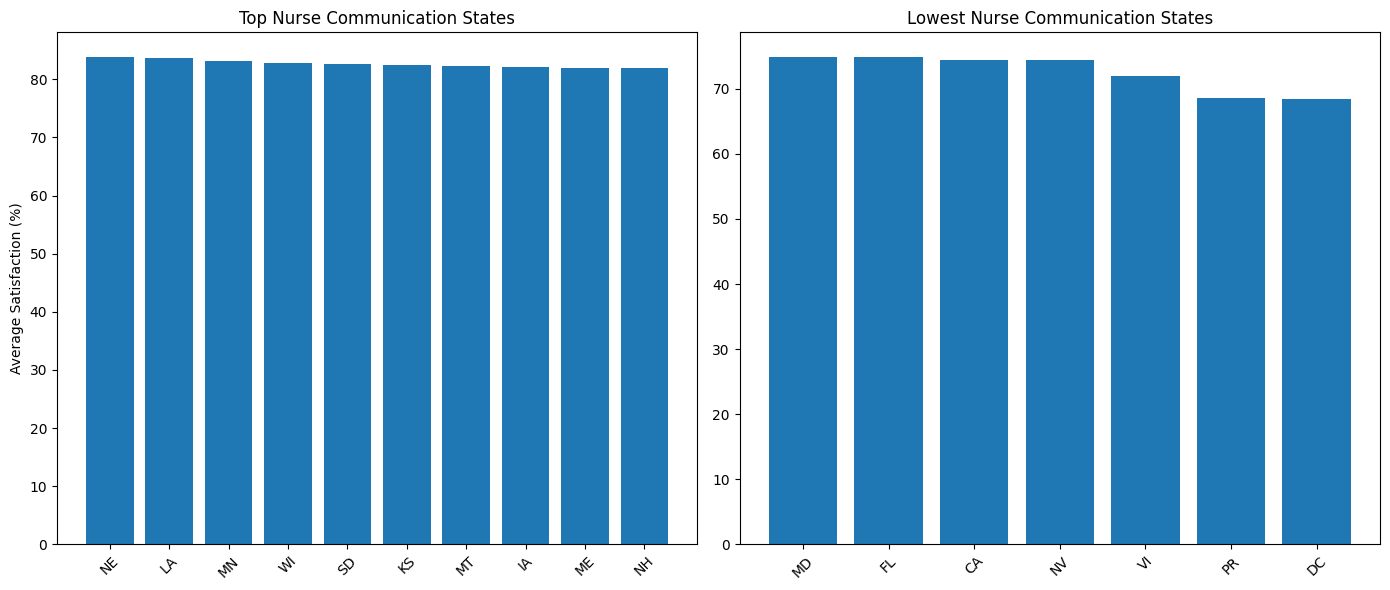

In [ ]:
# Visualize top and bottom nurse communication states

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top states
axes[0].bar(top_nurse_states.index, top_nurse_states.values)
axes[0].set_title('Top Nurse Communication States')
axes[0].set_ylabel('Average Satisfaction (%)')
axes[0].tick_params(axis='x', rotation=45)

# Bottom states
bottom_clean = bottom_nurse_states.dropna()

axes[1].bar(bottom_clean.index, bottom_clean.values)
axes[1].set_title('Lowest Nurse Communication States')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Average nurse communication score by hospital

hospital_nurse_scores = (
    nurse_comm_df.groupby('facility_name')['hcahps_answer_percent']
    .mean()
    .sort_values(ascending=False)
)

# Top and bottom hospitals
top_hospitals = hospital_nurse_scores.head(10)
bottom_hospitals = hospital_nurse_scores.tail(10)

top_hospitals, bottom_hospitals

(facility_name
 TOWNER COUNTY MEDICAL CENTER             99.0
 SCHEURER HOSPITAL                        99.0
 ST JAMES PARISH HOSPITAL                 98.0
 UNITY MEDICAL CENTER                     98.0
 EDGERTON HOSPITAL AND HEALTH SERVICES    98.0
 ERIE VA MEDICAL CENTER                   97.0
 LAKE VIEW MEMORIAL HOSPITAL              97.0
 FRANKLIN GENERAL HOSPITAL                97.0
 TROUSDALE MEDICAL CENTER                 97.0
 ALEXANDRIA VA MEDICAL CENTER             97.0
 Name: hcahps_answer_percent, dtype: float64,
 facility_name
 WEST VALLEY HOSPITAL                     NaN
 WESTON COUNTY HEALTH SERVICES            NaN
 WHEATLAND MEMORIAL HOSPITAL              NaN
 WHITFIELD MEDICAL SURGICAL HOSPITAL      NaN
 WICHITA COUNTY HEALTH CENTER             NaN
 WILMINGTON TREATMENT CENTER              NaN
 WILSON N JONES REGIONAL MEDICAL CENTER   NaN
 WINKLER COUNTY MEMORIAL HOSPITAL         NaN
 WOODS AT PARKSIDE,THE                    NaN
 YUMA DISTRICT HOSPITAL                 

In [ ]:
# Remove hospitals with missing satisfaction values

hospital_nurse_scores_clean = hospital_nurse_scores.dropna()

# Recalculate rankings
top_hospitals_clean = hospital_nurse_scores_clean.head(10)
bottom_hospitals_clean = hospital_nurse_scores_clean.tail(10)

top_hospitals_clean, bottom_hospitals_clean

(facility_name
 TOWNER COUNTY MEDICAL CENTER             99.0
 SCHEURER HOSPITAL                        99.0
 ST JAMES PARISH HOSPITAL                 98.0
 UNITY MEDICAL CENTER                     98.0
 EDGERTON HOSPITAL AND HEALTH SERVICES    98.0
 ERIE VA MEDICAL CENTER                   97.0
 LAKE VIEW MEMORIAL HOSPITAL              97.0
 FRANKLIN GENERAL HOSPITAL                97.0
 TROUSDALE MEDICAL CENTER                 97.0
 ALEXANDRIA VA MEDICAL CENTER             97.0
 Name: hcahps_answer_percent, dtype: float64,
 facility_name
 BAYAMON MEDICAL CENTER            58.0
 LOS ANGELES COMMUNITY HOSPITAL    57.0
 DELRAY MEDICAL CENTER             56.0
 MEMORIAL HOSPITAL OF GARDENA      56.0
 JACKSON PARK HOSPITAL             54.0
 COMMUNITY FIRST MEDICAL CENTER    52.0
 COLUSA MEDICAL CENTER             52.0
 COAST PLAZA HOSPITAL              51.0
 LORETTO HOSPITAL                  49.0
 GLENN MEDICAL CENTER              48.0
 Name: hcahps_answer_percent, dtype: float64)

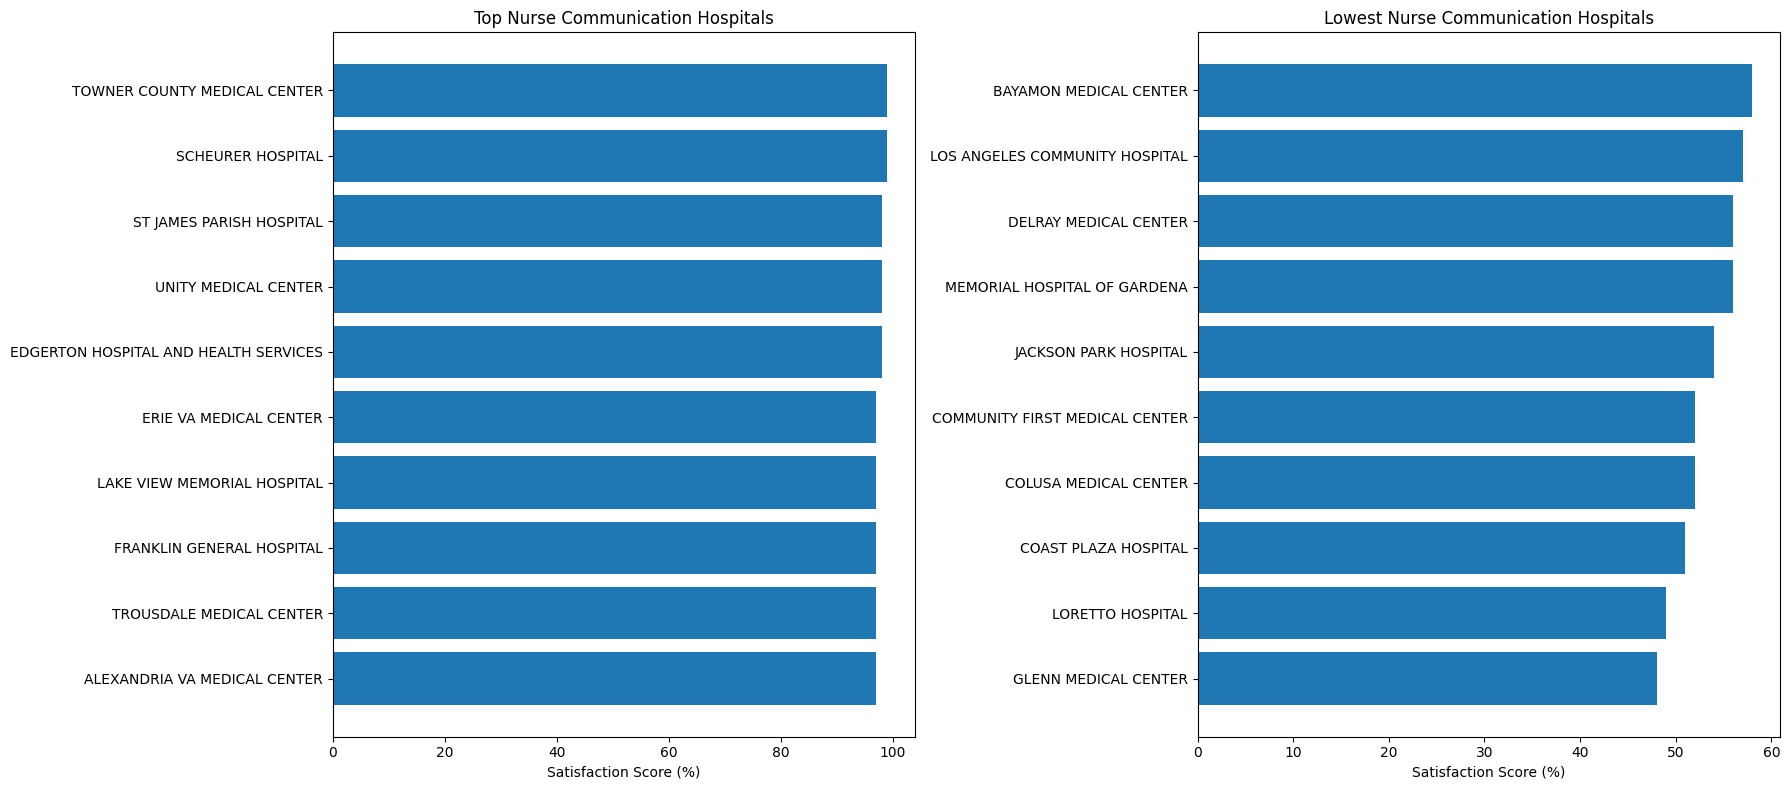

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top hospitals
axes[0].barh(top_hospitals_clean.index, top_hospitals_clean.values)
axes[0].set_title('Top Nurse Communication Hospitals')
axes[0].set_xlabel('Satisfaction Score (%)')
axes[0].invert_yaxis()

# Bottom hospitals
axes[1].barh(bottom_hospitals_clean.index, bottom_hospitals_clean.values)
axes[1].set_title('Lowest Nurse Communication Hospitals')
axes[1].set_xlabel('Satisfaction Score (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# Load Medicare spending dataset
spending_df = pd.read_csv('/content/medicare_hospital_spending_per_patient_hospital.csv')

# Preview dataset
spending_df.head()

,facility_id,facility_name,address,citytown,state,zip_code,countyparish,telephone_number,measure_id,measure_name,score,footnote,start_date,end_date
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MSPB-1,Medicare hospital spending per patient (Medica...,1.04,NaN,2022-01-01,2022-12-31
1,10005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,MSPB-1,Medicare hospital spending per patient (Medica...,0.95,NaN,2022-01-01,2022-12-31
2,10006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 629-1000,MSPB-1,Medicare hospital spending per patient (Medica...,1.00,NaN,2022-01-01,2022-12-31
3,10007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,MSPB-1,Medicare hospital spending per patient (Medica...,1.01,NaN,2022-01-01,2022-12-31
4,10008,CRENSHAW COMMUNITY HOSPITAL,101 HOSPITAL CIRCLE,LUVERNE,AL,36049,CRENSHAW,(334) 335-3374,MSPB-1,Medicare hospital spending per patient (Medica...,1.11,NaN,2022-01-01,2022-12-31


In [ ]:
# Dataset structure
spending_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4615 entries, 0 to 4614
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   facility_id       4615 non-null   int64  
 1   facility_name     4615 non-null   object 
 2   address           4615 non-null   object 
 3   citytown          4615 non-null   object 
 4   state             4615 non-null   object 
 5   zip_code          4615 non-null   int64  
 6   countyparish      4615 non-null   object 
 7   telephone_number  4615 non-null   object 
 8   measure_id        4615 non-null   object 
 9   measure_name      4615 non-null   object 
 10  score             2939 non-null   float64
 11  footnote          1676 non-null   float64
 12  start_date        4615 non-null   object 
 13  end_date          4615 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 504.9+ KB


In [ ]:
# Check missing values
spending_df.isnull().sum()

,0
facility_id,0
facility_name,0
address,0
citytown,0
state,0
zip_code,0
countyparish,0
telephone_number,0
measure_id,0
measure_name,0


In [ ]:
# Remove rows with missing spending scores
spending_cleaned = spending_df.dropna(subset=['score'])

# Verify cleaning
spending_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2939 entries, 0 to 4607
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   facility_id       2939 non-null   int64  
 1   facility_name     2939 non-null   object 
 2   address           2939 non-null   object 
 3   citytown          2939 non-null   object 
 4   state             2939 non-null   object 
 5   zip_code          2939 non-null   int64  
 6   countyparish      2939 non-null   object 
 7   telephone_number  2939 non-null   object 
 8   measure_id        2939 non-null   object 
 9   measure_name      2939 non-null   object 
 10  score             2939 non-null   float64
 11  footnote          0 non-null      float64
 12  start_date        2939 non-null   object 
 13  end_date          2939 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 344.4+ KB


In [ ]:
# Average spending by state
state_spending = spending_cleaned.groupby('state')['score'].mean().sort_values(ascending=False)

# Top and bottom states
top_spending_states = state_spending.head(10)
bottom_spending_states = state_spending.tail(10)

top_spending_states, bottom_spending_states

(state
 LA    1.077403
 NJ    1.068197
 TX    1.041679
 NV    1.034000
 AR    1.022195
 DE    1.021667
 MS    1.018846
 IN    1.014750
 NY    1.013780
 TN    1.011818
 Name: score, dtype: float64,
 state
 UT    0.935312
 WA    0.929778
 VT    0.928333
 WI    0.926562
 MN    0.919556
 ND    0.917143
 HI    0.907500
 MT    0.904545
 OR    0.893030
 AK    0.876250
 Name: score, dtype: float64)

# Nurse Communication Performance

Communication quality strongly impacts patient satisfaction and healthcare outcomes.

This section identifies the hospitals and states with the strongest and weakest nurse communication scores.

In [ ]:
# Nurse communication satisfaction by hospital
hospital_satisfaction = hcahps_cleaned[
    hcahps_cleaned['hcahps_question'].str.contains(
        'nurses "Always" communicated well',
        case=False,
        na=False
    )
]

# Average satisfaction per hospital
hospital_satisfaction_scores = hospital_satisfaction.groupby(
    'facility_id'
)['hcahps_answer_percent'].mean().reset_index()

# Rename column
hospital_satisfaction_scores.columns = [
    'facility_id',
    'satisfaction_score'
]

hospital_satisfaction_scores.head()

,facility_id,satisfaction_score
0,10001.0,72.0
1,10005.0,78.0
2,10006.0,73.0
3,10007.0,80.0
4,10008.0,85.0


In [ ]:
# Average spending per hospital
hospital_spending_scores = spending_cleaned.groupby(
    'facility_id'
)['score'].mean().reset_index()

# Rename column
hospital_spending_scores.columns = [
    'facility_id',
    'spending_score'
]

hospital_spending_scores.head()

,facility_id,spending_score
0,10001,1.04
1,10005,0.95
2,10006,1.00
3,10007,1.01
4,10008,1.11


In [ ]:
# Merge datasets
merged_scores = pd.merge(
    hospital_satisfaction_scores,
    hospital_spending_scores,
    on='facility_id',
    how='inner'
)

merged_scores.head()

,facility_id,satisfaction_score,spending_score
0,10001.0,72.0,1.04
1,10005.0,78.0,0.95
2,10006.0,73.0,1.00
3,10007.0,80.0,1.01
4,10008.0,85.0,1.11


In [ ]:
# Correlation between spending and satisfaction
correlation = merged_scores[
    ['satisfaction_score', 'spending_score']
].corr()

correlation

,satisfaction_score,spending_score
satisfaction_score,1.000000,-0.232713
spending_score,-0.232713,1.000000


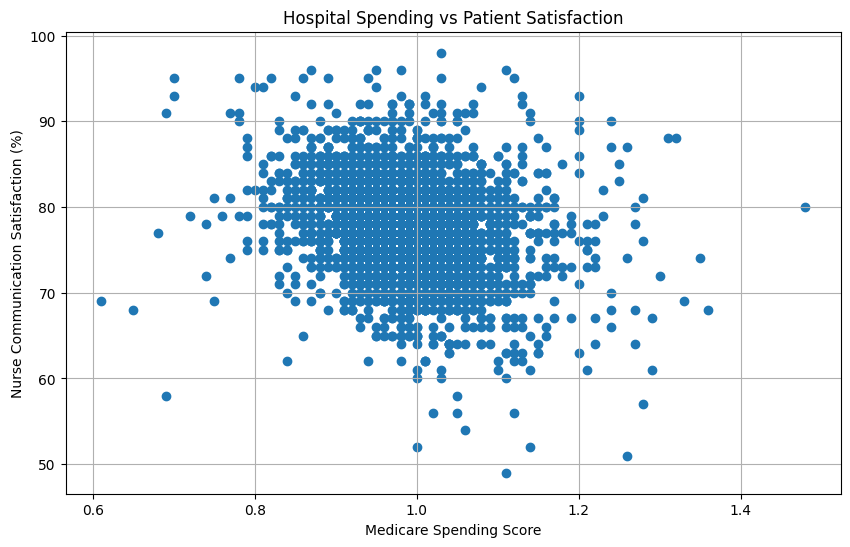

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot
plt.figure(figsize=(10,6))

plt.scatter(
    merged_scores['spending_score'],
    merged_scores['satisfaction_score']
)

plt.title('Hospital Spending vs Patient Satisfaction')
plt.xlabel('Medicare Spending Score')
plt.ylabel('Nurse Communication Satisfaction (%)')

plt.grid(True)

plt.show()

In [ ]:
# Remove any remaining invalid rows
merged_scores_clean = merged_scores.dropna()

# Verify
merged_scores_clean.isnull().sum()

,0
facility_id,0
satisfaction_score,0
spending_score,0


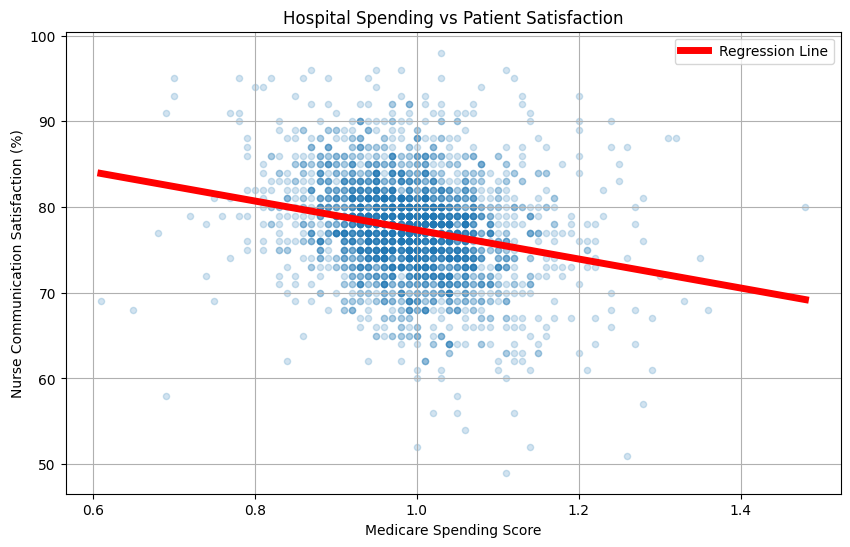

Slope: -16.92119479937701
Intercept: 94.23886127788731


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = merged_scores_clean['spending_score']
y = merged_scores_clean['satisfaction_score']

# Regression calculation
m, b = np.polyfit(x, y, 1)

# Create regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b

plt.figure(figsize=(10,6))

# Scatter plot
plt.scatter(
    x,
    y,
    alpha=0.2,
    s=20
)

# Regression line
plt.plot(
    x_line,
    y_line,
    color='red',
    linewidth=5,
    zorder=10,
    label='Regression Line'
)

plt.title('Hospital Spending vs Patient Satisfaction')
plt.xlabel('Medicare Spending Score')
plt.ylabel('Nurse Communication Satisfaction (%)')

plt.legend()
plt.grid(True)

plt.show()

print("Slope:", m)
print("Intercept:", b)

In [ ]:
complications_df.head()

,facility_id,facility_name,address,citytown,state,zip_code,countyparish,telephone_number,measure_id,measure_name,compared_to_national,denominator,score,lower_estimate,higher_estimate,footnote,start_date,end_date
0,10001.0,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,COMP_HIP_KNEE,Rate of complications for hip/knee replacement...,No Different Than the National Rate,32.0,3.0,1.6,5.5,NaN,2020-07-01,2023-03-31
1,10001.0,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_AMI,Death rate for heart attack patients,No Different Than the National Rate,291.0,10.8,8.4,13.6,NaN,2020-07-01,2023-06-30
2,10001.0,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_CABG,Death rate for CABG surgery patients,No Different Than the National Rate,157.0,3.8,2.1,6.8,NaN,2020-07-01,2023-06-30
3,10001.0,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_COPD,Death rate for COPD patients,No Different Than the National Rate,122.0,7.9,5.2,11.9,NaN,2020-07-01,2023-06-30
4,10001.0,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_HF,Death rate for heart failure patients,No Different Than the National Rate,610.0,10.5,8.6,12.9,NaN,2020-07-01,2023-06-30


In [ ]:
complications_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90801 entries, 0 to 90800
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   facility_id           87685 non-null  float64       
 1   facility_name         90801 non-null  object        
 2   address               90801 non-null  object        
 3   citytown              90801 non-null  object        
 4   state                 90801 non-null  object        
 5   zip_code              90801 non-null  int64         
 6   countyparish          90801 non-null  object        
 7   telephone_number      90801 non-null  object        
 8   measure_id            90801 non-null  object        
 9   measure_name          90801 non-null  object        
 10  compared_to_national  90801 non-null  object        
 11  denominator           90801 non-null  float64       
 12  score                 90801 non-null  float64       
 13  lower_estimate  

In [ ]:
complications_df.columns

Index(['facility_id', 'facility_name', 'address', 'citytown', 'state',
       'zip_code', 'countyparish', 'telephone_number', 'measure_id',
       'measure_name', 'compared_to_national', 'denominator', 'score',
       'lower_estimate', 'higher_estimate', 'footnote', 'start_date',
       'end_date'],
      dtype='object')

In [ ]:
timely_df.head()

,facility_id,facility_name,address,citytown,state,zip_code,countyparish,telephone_number,condition,measure_id,measure_name,score,sample,footnote,start_date,end_date
0,10001.0,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Emergency Department,EDV,Emergency department volume,NaN,NaN,NaN,2022-01-01,2022-12-31
1,10001.0,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Electronic Clinical Quality Measure,ED_2_Strata_1,Admit Decision Time to ED Departure Time for A...,NaN,NaN,5.0,2023-01-01,2023-12-31
2,10001.0,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Electronic Clinical Quality Measure,ED_2_Strata_2,Admit Decision Time to ED Departure Time for A...,NaN,NaN,5.0,2023-01-01,2023-12-31
3,10001.0,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Healthcare Personnel Vaccination,HCP_COVID_19,Percentage of healthcare personnel who are up ...,0.0,2712.0,NaN,2023-10-01,2023-12-31
4,10001.0,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Electronic Clinical Quality Measure,HH_01,Hospital Harm - Severe Hypoglycemia,NaN,NaN,5.0,2023-01-01,2023-12-31


In [ ]:
timely_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118520 entries, 0 to 118519
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   facility_id       118072 non-null  float64
 1   facility_name     118520 non-null  object 
 2   address           118520 non-null  object 
 3   citytown          118520 non-null  object 
 4   state             118520 non-null  object 
 5   zip_code          118520 non-null  int64  
 6   countyparish      118520 non-null  object 
 7   telephone_number  118520 non-null  object 
 8   condition         118520 non-null  object 
 9   measure_id        118520 non-null  object 
 10  measure_name      118520 non-null  object 
 11  score             50726 non-null   float64
 12  sample            51697 non-null   float64
 13  footnote          71660 non-null   float64
 14  start_date        118520 non-null  object 
 15  end_date          118520 non-null  object 
dtypes: float64(4), int64

In [ ]:
timely_df.columns

Index(['facility_id', 'facility_name', 'address', 'citytown', 'state',
       'zip_code', 'countyparish', 'telephone_number', 'condition',
       'measure_id', 'measure_name', 'score', 'sample', 'footnote',
       'start_date', 'end_date'],
      dtype='object')

In [ ]:
state_complication_scores = (
    complications_df
    .groupby('state')['score']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

state_complication_scores.head(10)

,state,score
0,NJ,11.309093
1,MD,10.741469
2,DC,10.497368
3,FL,9.769033
4,CT,9.392368
5,MA,8.825279
6,NY,8.159693
7,VA,8.143533
8,SC,7.827985
9,DE,7.672105


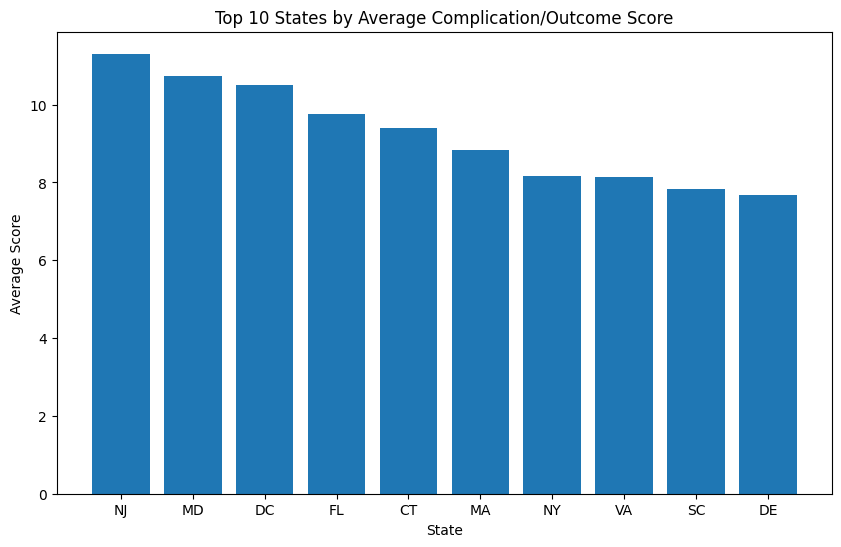

In [ ]:
import matplotlib.pyplot as plt

top_states = state_complication_scores.head(10)

plt.figure(figsize=(10,6))
plt.bar(top_states['state'], top_states['score'])

plt.title('Top 10 States by Average Complication/Outcome Score')
plt.xlabel('State')
plt.ylabel('Average Score')

plt.show()

In [ ]:
timely_state_scores = (
    timely_df
    .dropna(subset=['score'])
    .groupby('state')['score']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

timely_state_scores.head(10)

,state,score
0,DC,112.154023
1,MA,109.331343
2,MD,105.432964
3,ME,98.256303
4,DE,97.100000
5,VT,94.385039
6,NC,94.126853
7,RI,94.098621
8,NJ,93.702246
9,CT,92.519685


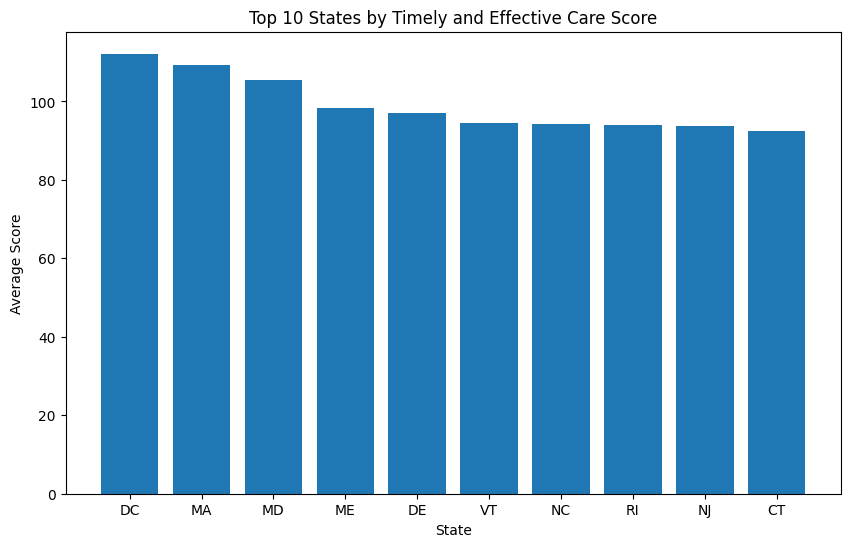

In [ ]:
top_timely_states = timely_state_scores.head(10)

plt.figure(figsize=(10,6))
plt.bar(top_timely_states['state'], top_timely_states['score'])

plt.title('Top 10 States by Timely and Effective Care Score')
plt.xlabel('State')
plt.ylabel('Average Score')

plt.show()

# Final Conclusions

## Key Findings
- Certain states consistently showed higher complication scores.
- Patient satisfaction varied significantly across hospitals and regions.
- Some hospitals demonstrated strong communication scores despite moderate spending.
- Higher Medicare spending did not always correspond to better outcomes.

---

## Business Impact
Healthcare organizations can use this analysis to:
- Identify underperforming regions
- Improve patient communication strategies
- Optimize spending efficiency
- Monitor healthcare quality trends

---

## Skills Demonstrated
- Data Cleaning
- Exploratory Data Analysis
- Data Visualization
- Statistical Analysis
- Healthcare Analytics
- Python Programming
- Real-world Data Handling

In [1]:
!jupyter nbconvert --to pdf "/content/healthcare.ipynb"

[NbConvertApp] WARNING | pattern '/content/healthcare.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--exe

In [ ]:
!apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-extra texlive-latex-recommended texlive-pictures tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf libavalon-framework-java
  libcommons-logging-java-doc libexcalibur-logkit-java 